In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Imports

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_google_vertexai import ChatVertexAI
import matplotlib.pyplot as plt

from wsd.load_data import load_data
from wsd.models import BinaryWSD, ClusterByMeaningModel, DummyComparator
from linpub.metrics import accuracy

from lineval.utils import (load_hub_docs,
                           check_assign_docs,
                           OpenAiWordSenseComparatorv4,
                           ClusterByMeaningModelv4,
                           annotator_filter,
                           AnnotationSerializerv2,
                           AnnotationFactoryv2,
                           get_unique_senses,
                           plot_cluster_accuracy
)

from linalgo.annotate.models import Corpus, Document, Annotation, Target, Selector, Annotator
from lineval.utils import Body
from datetime import datetime
from collections import defaultdict
from dotenv import load_dotenv
import os

# Testing linhub loading capacity

In [ ]:
# Use create_...


# Loading candidates

In [150]:
#loading candidates
X, y = load_data(lang='fr')

k = 3000
X_test, y_test = X[:k], y[:k]
len(X_test), len(y_test)

(3000, 3000)

In [ ]:
# canidates to corpus
Semcor_corpus = Corpus(name='Semcor')

grouped_X = defaultdict(list)
for i,row in enumerate(X_test):
    row.lemma_meaning = y_test[i]
    grouped_X[(row.lemma, row.pos)].append(row)
items = grouped_X.items()
docs = []
for g, cands in items:
    contexts = "\n".join([anno.context for anno in cands])
    doc = Document(content=contexts,
                   corpus=Semcor_corpus
                   )
    doc_annos = []
    for c in cands:
        anno = Annotation(document=doc,
                          entity=c.lemma_meaning,
                          body=Body(text=c.text, context=c.context),
                          task="task",
                          annotator="none",
                          target={},
                          created=datetime.now())
        doc_annos.append(anno)
    doc.annotations = set(doc_annos)
    docs.append(doc)

Semcor_corpus.documents = docs
X_docs = Semcor_corpus.documents
len(X_docs)

## printing

In [ ]:
example_ano = list(Semcor_corpus.documents[0].annotations)[0]

Semcor_corpus.documents[0].__dict__, example_ano.__dict__, example_ano.annotator.__dict__

({'id': 'e8643ec0-2af7-4cde-bf71-80c8b4c5517b',
  'uri': None,
  'content': "Depuis combien de temps avez -vous revu les objectifs de votre programme de prestations et de services ?\nAvez -vous fixé des objectifs spécifiques pour votre publication d' employés ?\nAtteindre ces objectifs ?\nCet objectif est respecté pendant toute la durée de l' action .\nComme première étape vers cet objectif , des arrangements ont été élaborés pour comparer les échelles actuellement utilisées par la circulation d' un groupe de thermomètres de résistance à platine standard pour l' étalonnage par chaque laboratoire national .\nSon objectif est simplement de déterminer < < quelles distinctions de longueur et de syllabicité il peut être souhaitable de rendre explicite dans une orthographie de Kikuyu > > ( 59 ) .",
  'corpus': Corpus::Semcor,
  'annotations': {Annotation::0,
   Annotation::0,
   Annotation::bn:00002179n,
   Annotation::bn:00002179n,
   Annotation::bn:00002179n,
   Annotation::bn:00002179n}},

In [19]:
gold_annotator = Annotator(name="gold",
                           owner="jack",
                           model="MACHINE")
gold_annotator.__dict__

{'id': 'c74add88-d3e1-4819-abbd-9acb487780a3',
 'name': 'gold',
 'task': Task::default,
 'owner': 'jack',
 'model': 'MACHINE',
 'entity_id': None,
 'threshold': 0}

# Creating gold

In [20]:
# ONLY RUN ONCE!!!

for doc in X_docs:
    gold_annos = [anno for anno in doc.annotations if anno.annotator.name == None]
    for anno in gold_annos:
        a = Annotation(entity = anno.entity,
                       body=anno.body,
                       document=doc,
                       annotator = gold_annotator,
                       target = anno.target,
                       )
        doc.annotations.add(a)


In [21]:
list(X_docs[0].annotations)[0].__dict__

{'id': '9334d0cb-723c-4f63-922f-01f847408d39',
 'entity': Entity::bn:00002179n,
 'score': None,
 'body': Body(text='objectifs', extras={'context': 'Depuis combien de temps avez -vous revu les objectifs de votre programme de prestations et de services ?'}),
 'task': Task::default,
 'annotator': Annotator::gold,
 'document': Document::448c8594-a4f3-43f7-9a1d-8b6133a6b90c,
 'target': <linalgo.annotate.models.Target at 0x7f1bda36c250>,
 'created': datetime.datetime(2025, 2, 5, 16, 5, 53, 639772)}

# Predicting

## Base predict (avoid)

In [23]:
load_dotenv()
api_key = os.getenv("OPEN_AI_API_KEY")
comp_1 = OpenAiWordSenseComparatorv4(api_key=api_key, openai_model="gpt-4o", thought_process=False)
model_1 = ClusterByMeaningModelv4(word_sense_comparator=comp_1)

In [24]:
y_pred_docs = model_1.predict(X_docs)


            Compared objectifs in Depuis combien de temps avez -vous revu les objectifs de votre programme de prestations et de services ?
            with objectifs in Depuis combien de temps avez -vous revu les objectifs de votre programme de prestations et de services ?
            Proba: 1.0
            Process: reference word
            
Added objectifs to sense 0
{Annotation::bn:00002179n
, Annotation::bn:00002179n
, Annotation::bn:00002179n
, Annotation::0, Annotation::bn:00002179n
, Annotation::bn:00030721n
, Annotation::bn:00030721n
, Annotation::bn:00002179n
, Annotation::bn:00030721n
, Annotation::bn:00002179n
, Annotation::bn:00002179n
, Annotation::bn:00030721n
, Annotation::bn:00002179n
}

            Compared objectifs in Depuis combien de temps avez -vous revu les objectifs de votre programme de prestations et de services ?
            with objectif in Comme première étape vers cet objectif , des arrangements ont été élaborés pour comparer les échelles actuellement ut

In [114]:
dummy_1 = Annotator(name="dummy_1",
                           owner="jack",
                           model="MACHINE")
dummy_0 = Annotator(name="dummy_0",
                    owner="jack",
                    model="MACHINE")


for doc in X_docs:
    gold_annos = [anno for anno in doc.annotations if anno.annotator.name == "gold"]
    i = 0
    for anno in gold_annos:
        a = Annotation(entity = "0",
                       body=anno.body,
                       document=doc,
                       annotator = dummy_0,
                       target = anno.target,
                       )
        b = Annotation(entity = str(i),
                       body=anno.body,
                       document=doc,
                       annotator = dummy_1,
                       target = anno.target,
                       )
        i += 1
        doc.annotations.add(a)
        doc.annotations.add(b)

## batch predict (use)

In [8]:
# CODE HERE

# visualisations

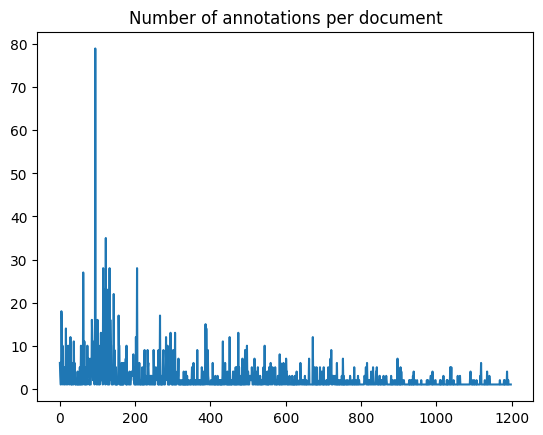

In [ ]:


doc_len = [len(list(doc.annotations)) for doc in X_docs]

plt.plot(doc_len)
plt.title("Number of annotations per document")
plt.show()

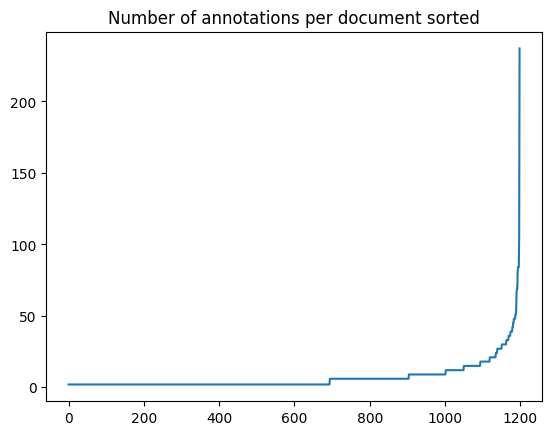

In [ ]:
X_docs_sorted = sorted(X_docs, key=lambda x: len(list(x.annotations)), reverse=False)

sorted_doc_len = [len(list(doc.annotations)) for doc in X_docs_sorted]

plt.plot(sorted_doc_len)
plt.title("Number of annotations per document (sorted)")
plt.show()

In [64]:
sorted_doc_len[0]

2

In [145]:
# removing docs with only 2 annotations(Semcor and gold)
X_docs_filtered = [doc for doc in X_docs if len(list(doc.annotations)) > 2]
X_docs_filtered.sort(key=lambda x: len(list(x.annotations)), reverse=False)
len(X_docs_filtered)

1199

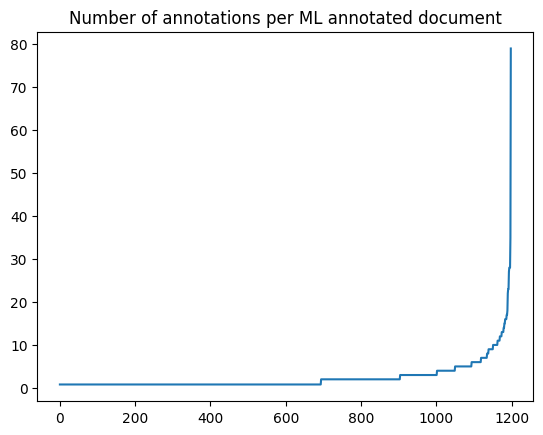

In [161]:
plt.plot([len(list(doc.annotations))/5 for doc in X_docs_filtered])
plt.title("Number of annotations per ML annotated document")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

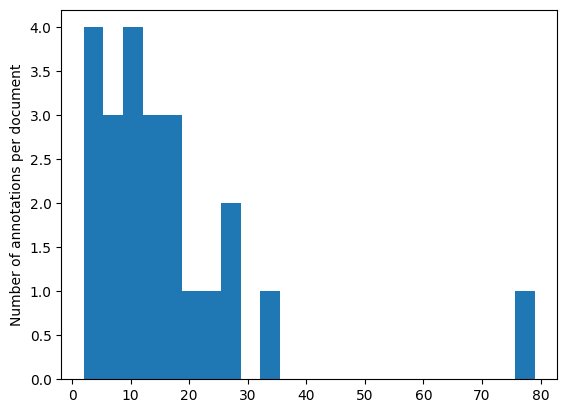

In [140]:
nb_annos = set(int(len(list(doc.annotations))/5) for doc in X_docs_filtered)
plt.hist(nb_annos, bins = 23 )
plt.ylabel("Number of annotations per document")
plt.show
#sort the set

In [141]:
nb_annos = list(sorted(nb_annos))
len(nb_annos), nb_annos

(23,
 [2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  22,
  23,
  27,
  28,
  35,
  79])

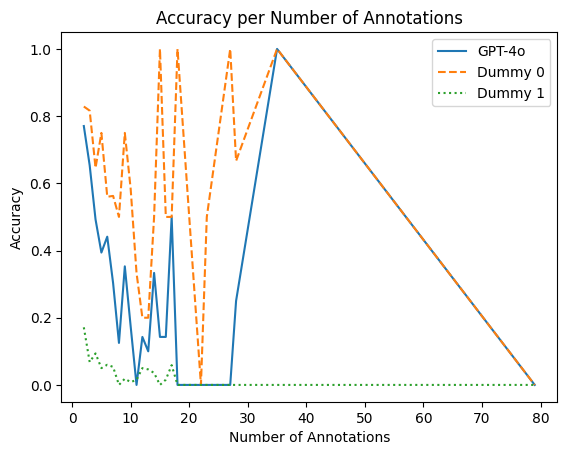

In [132]:
accs = []
dummy_0_accs = []
dummy_1_accs = []

for x_val in nb_annos:
    y = []
    y_pred = []
    dummy_0_y_pred = []
    dummy_1_y_pred = []

    for doc in X_docs_filtered:
        if len(list(doc.annotations)) == x_val * 5:
            for anno in sorted(doc.annotations, key=lambda x: x.body.context):
                sense = hash((doc, anno.entity.id))
                if anno.annotator.name == "gold":
                    y.append(sense)
                if anno.annotator.name == "gpt-4o_tp_False":
                    y_pred.append(sense)
                if anno.annotator.name == "dummy_0":
                    dummy_0_y_pred.append(sense)
                if anno.annotator.name == "dummy_1":
                    dummy_1_y_pred.append(sense)

    if len(y) > 0:
        accs.append(accuracy(y_pred, y))
        dummy_0_accs.append(accuracy(dummy_0_y_pred, y))
        dummy_1_accs.append(accuracy(dummy_1_y_pred, y))

plt.plot(nb_annos, accs, label="GPT-4o")
plt.plot(nb_annos, dummy_0_accs, label="Dummy 0", linestyle="--")
plt.plot(nb_annos, dummy_1_accs, label="Dummy 1", linestyle=":")

plt.title("Accuracy per Number of Annotations")
plt.xlabel("Number of Annotations")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [158]:
nb_clust = []
for doc in X_docs_filtered:
    gold_annos = [anno for anno in doc.annotations if anno.annotator.name == "gold"]
    local_clusters = len(set( anno.entity.id for anno in gold_annos))
    nb_clust.append(local_clusters)
cluster_sizes = list(sorted(set(nb_clust)))
cluster_sizes

[1, 2, 3, 4, 6]

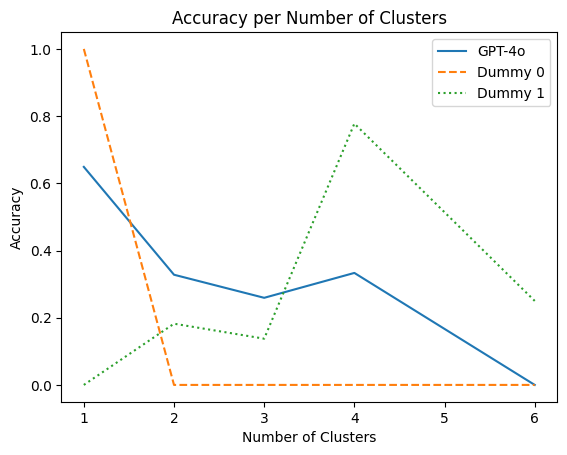

In [133]:
accs=[]
dummy_0_accs = []
dummy_1_accs = []
for x_val in cluster_sizes:
    y=[]
    y_pred=[]
    dummy_0_y_pred = []
    dummy_1_y_pred = []
    for doc in X_docs_filtered:
        gold_annos = [anno for anno in doc.annotations if anno.annotator.name == "gold"]
        local_clusters = len(set( anno.entity.id for anno in gold_annos))
        if local_clusters == x_val:
            for anno in sorted(doc.annotations, key=lambda x: x.body.context):
                sense = hash((doc, anno.entity.id))
                if anno.annotator.name == "gold":
                    y.append(sense)
                if anno.annotator.name == "gpt-4o_tp_False":
                    y_pred.append(sense)
                if anno.annotator.name == "dummy_0":
                    dummy_0_y_pred.append(sense)
                if anno.annotator.name == "dummy_1":
                    dummy_1_y_pred.append(sense)
    if len(y) > 0:
        accs.append(accuracy(y_pred, y))
        dummy_0_accs.append(accuracy(dummy_0_y_pred, y))
        dummy_1_accs.append(accuracy(dummy_1_y_pred, y))

import matplotlib.pyplot as plt

accs = []
dummy_0_accs = []
dummy_1_accs = []

for x_val in cluster_sizes:
    y = []
    y_pred = []
    dummy_0_y_pred = []
    dummy_1_y_pred = []

    for doc in X_docs_filtered:
        gold_annos = [anno for anno in doc.annotations if anno.annotator.name == "gold"]
        local_clusters = len(set(anno.entity.id for anno in gold_annos))

        if local_clusters == x_val:
            for anno in sorted(doc.annotations, key=lambda x: x.body.context):
                sense = hash((doc, anno.entity.id))
                if anno.annotator.name == "gold":
                    y.append(sense)
                if anno.annotator.name == "gpt-4o_tp_False":
                    y_pred.append(sense)
                if anno.annotator.name == "dummy_0":
                    dummy_0_y_pred.append(sense)
                if anno.annotator.name == "dummy_1":
                    dummy_1_y_pred.append(sense)

    if len(y) > 0:
        accs.append(accuracy(y_pred, y))
        dummy_0_accs.append(accuracy(dummy_0_y_pred, y))
        dummy_1_accs.append(accuracy(dummy_1_y_pred, y))

# Plot accuracy vs. number of clusters
plt.plot(cluster_sizes, accs, label="GPT-4o")
plt.plot(cluster_sizes, dummy_0_accs, label="Dummy 0", linestyle="--")
plt.plot(cluster_sizes, dummy_1_accs, label="Dummy 1", linestyle=":")

plt.title("Accuracy per Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
# Dummy 1 seems very good, let's check the average number of annotations per cluster


In [162]:
plot_cluster_accuracy(X_docs_filtered[:200])

Annotators : [Annotator::none, Annotator::gold, Annotator::dummy_1, Annotator::dummy_0]


y_pred,nan,dummy_0,dummy_1,gold
y,,,,
nan,nan,1.000000,1.000000,1.000000
dummy_0,1.000000,nan,1.000000,1.000000
dummy_1,1.000000,1.000000,nan,1.000000
gold,1.000000,1.000000,1.000000,nan


In [124]:
plot_cluster_accuracy(X_docs_filtered[:400])

Annotators : [Annotator::none, Annotator::gpt-4o_tp_False, Annotator::dummy_1, Annotator::gold, Annotator::dummy_0]


y_pred,nan,dummy_0,dummy_1,gold,gpt-4o_tp_False
y,,,,,
nan,nan,0.795000,0.107460,1.000000,0.654762
dummy_0,0.648980,nan,0.000000,0.648980,0.611111
dummy_1,0.246939,0.000000,nan,0.246939,0.267857
gold,1.000000,0.795000,0.107460,nan,0.654762
gpt-4o_tp_False,0.673469,0.770000,0.119893,0.673469,nan


In [125]:
plot_cluster_accuracy(X_docs_filtered[:450])

Annotators : [Annotator::none, Annotator::gpt-4o_tp_False, Annotator::dummy_1, Annotator::gold, Annotator::dummy_0]


y_pred,nan,dummy_0,dummy_1,gold,gpt-4o_tp_False
y,,,,,
nan,nan,0.768889,0.093515,1.000000,0.609881
dummy_0,0.611307,nan,0.000000,0.611307,0.574106
dummy_1,0.242049,0.000000,nan,0.242049,0.272572
gold,1.000000,0.768889,0.093515,nan,0.609881
gpt-4o_tp_False,0.632509,0.748889,0.109215,0.632509,nan


In [147]:
plot_cluster_accuracy(X_docs_filtered)

Annotators : [Annotator::none, Annotator::gpt-4o_tp_False, Annotator::dummy_1, Annotator::gold, Annotator::dummy_0]


y_pred,nan,dummy_0,dummy_1,gold,gpt-4o_tp_False
y,,,,,
nan,nan,0.891576,0.281333,1.000000,0.544396
dummy_0,0.792439,nan,0.231333,0.792439,0.537118
dummy_1,0.625649,0.578816,nan,0.625649,0.276565
gold,1.000000,0.891576,0.281333,nan,0.544396
gpt-4o_tp_False,0.570992,0.730693,0.082394,0.570992,nan


In [148]:
#last 50 docs
plot_cluster_accuracy(X_docs_filtered[-50:])

Annotators : [Annotator::none, Annotator::gpt-4o_tp_False, Annotator::dummy_1, Annotator::gold, Annotator::dummy_0]


y_pred,nan,dummy_0,dummy_1,gold,gpt-4o_tp_False
y,,,,,
nan,nan,0.500000,0.015075,1.000000,0.150538
dummy_0,0.301205,nan,0.000000,0.301205,0.311828
dummy_1,0.144578,0.000000,nan,0.144578,0.301075
gold,1.000000,0.500000,0.015075,nan,0.150538
gpt-4o_tp_False,0.168675,0.580000,0.035176,0.168675,nan
